# 02. Feature Engineering

DAY 1 보고서의 피처 전략(Set A / Set B)을 `src/features.py`로 구현한 결과를 확인합니다. 계산 로직은 이 노트북이 아니라 `src/features.py`에 있습니다.

| 세트 | 피처 | 정의 |
|---|---|---|
| A (최종 후보) | dq_log10_var, dq_kurtosis | ΔQ(V) = Qdlin(cycle 100) - Qdlin(cycle 10)의 log10(분산), 첨도 |
| B (비교용) | A + dq_skew, qd_init, qd_slope, tmax, c2, switch_pct | 왜도, 사이클 2~6 용량 중앙값, 사이클 2~100 용량 기울기(Ah/100사이클), 사이클 2~100 Tmax 중앙값, 충전 프로토콜 C2와 전환 지점 |

In [1]:
import sys; sys.path.append("..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from src.config import *
plt.rcParams.update({"font.family": "AppleGothic", "axes.unicode_minus": False, "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
C = {"batch1": "#1f77b4", "batch2": "#e07b00"}
from src.load_data import load_batch
from src.preprocess import select_valid
from src.features import FEATURE_SETS, TARGET, build_feature_table
cells1, _ = select_valid(load_batch("batch1"))
cells2, _ = select_valid(load_batch("batch2"))
T1, T2 = build_feature_table(cells1), build_feature_table(cells2)
print("Batch 1:", T1.shape, "| Batch 2:", T2.shape, "| 피처 결측:", int(T1[FEATURE_SETS["B"]].isna().sum().sum() + T2[FEATURE_SETS["B"]].isna().sum().sum()))
display(T1[FEATURE_SETS["B"]].describe().round(3))

Batch 1: (46, 12) | Batch 2: (39, 12) | 피처 결측: 0


,dq_log10_var,dq_kurtosis,dq_skew,qd_init,qd_slope,tmax,c2,switch_pct
count,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000
mean,-3.921,-1.114,-0.229,1.081,-0.001,35.867,3.583,51.522
std,0.395,0.831,0.215,0.008,0.003,1.639,0.584,19.461
min,-5.136,-1.383,-0.827,1.056,-0.014,30.582,3.000,15.000
25%,-4.044,-1.281,-0.343,1.077,-0.001,35.024,3.000,40.000
50%,-3.839,-1.252,-0.215,1.081,-0.001,36.196,3.600,50.000
75%,-3.666,-1.199,-0.106,1.084,0.001,36.852,3.600,67.500
max,-3.342,4.371,0.256,1.097,0.003,37.988,5.400,80.000


## 피처 선택 근거 확인 (Batch 1)

보고서의 선택 규칙 (1) Batch 1에서 |ρ| ≥ 0.3, (3) VIF < 5를 Batch 1 데이터로 다시 확인합니다. 테스트인 Batch 2의 cycle_life는 사용하지 않습니다.

In [2]:
rows = []
for f in FEATURE_SETS["B"]:
    rho = stats.spearmanr(T1[f], T1[TARGET])[0]
    rows.append({"feature": f, "세트": "A" if f in FEATURE_SETS["A"] else "B", "Spearman (Batch 1)": rho})
display(pd.DataFrame(rows).set_index("feature").round(2))

def vif(df):
    X = (df - df.mean()) / df.std()
    out = {}
    for c in X.columns:
        others = X.drop(columns=c).values
        beta, *_ = np.linalg.lstsq(np.c_[np.ones(len(X)), others], X[c].values, rcond=None)
        resid = X[c].values - np.c_[np.ones(len(X)), others] @ beta
        out[c] = 1 / (resid.var() / X[c].var(ddof=0)) if resid.var() > 0 else np.inf
    return pd.Series(out)
print("VIF (Set A):"); display(vif(T1[FEATURE_SETS["A"]]).round(2).to_frame("VIF").T)
print("VIF (Set B):"); display(vif(T1[FEATURE_SETS["B"]]).round(2).to_frame("VIF").T)

,세트,Spearman (Batch 1)
feature,,
dq_log10_var,A,-0.85
dq_kurtosis,A,0.31
dq_skew,B,-0.57
qd_init,B,0.08
qd_slope,B,0.58
tmax,B,-0.32
c2,B,0.05
switch_pct,B,0.19


VIF (Set A):


,dq_log10_var,dq_kurtosis
VIF,1.01,1.01


VIF (Set B):


,dq_log10_var,dq_kurtosis,dq_skew,qd_init,qd_slope,tmax,c2,switch_pct
VIF,2.46,1.86,3.33,1.24,2.87,1.42,1.82,1.98


**해석**: Set A의 두 피처는 VIF가 낮아 함께 써도 다중공선성 문제가 크지 않습니다. Set B에서 추가한 피처는 상관이 약하거나 서로 겹쳐서, 추가했을 때 이득이 있는지는 `03_modeling`의 교차검증으로 판단했습니다.

## 학습(Batch 1)과 평가(Batch 2) 피처 분포 비교

cycle_life를 쓰지 않고 입력 피처만 비교합니다. 두 배치의 분포가 얼마나 다른지 봅니다.

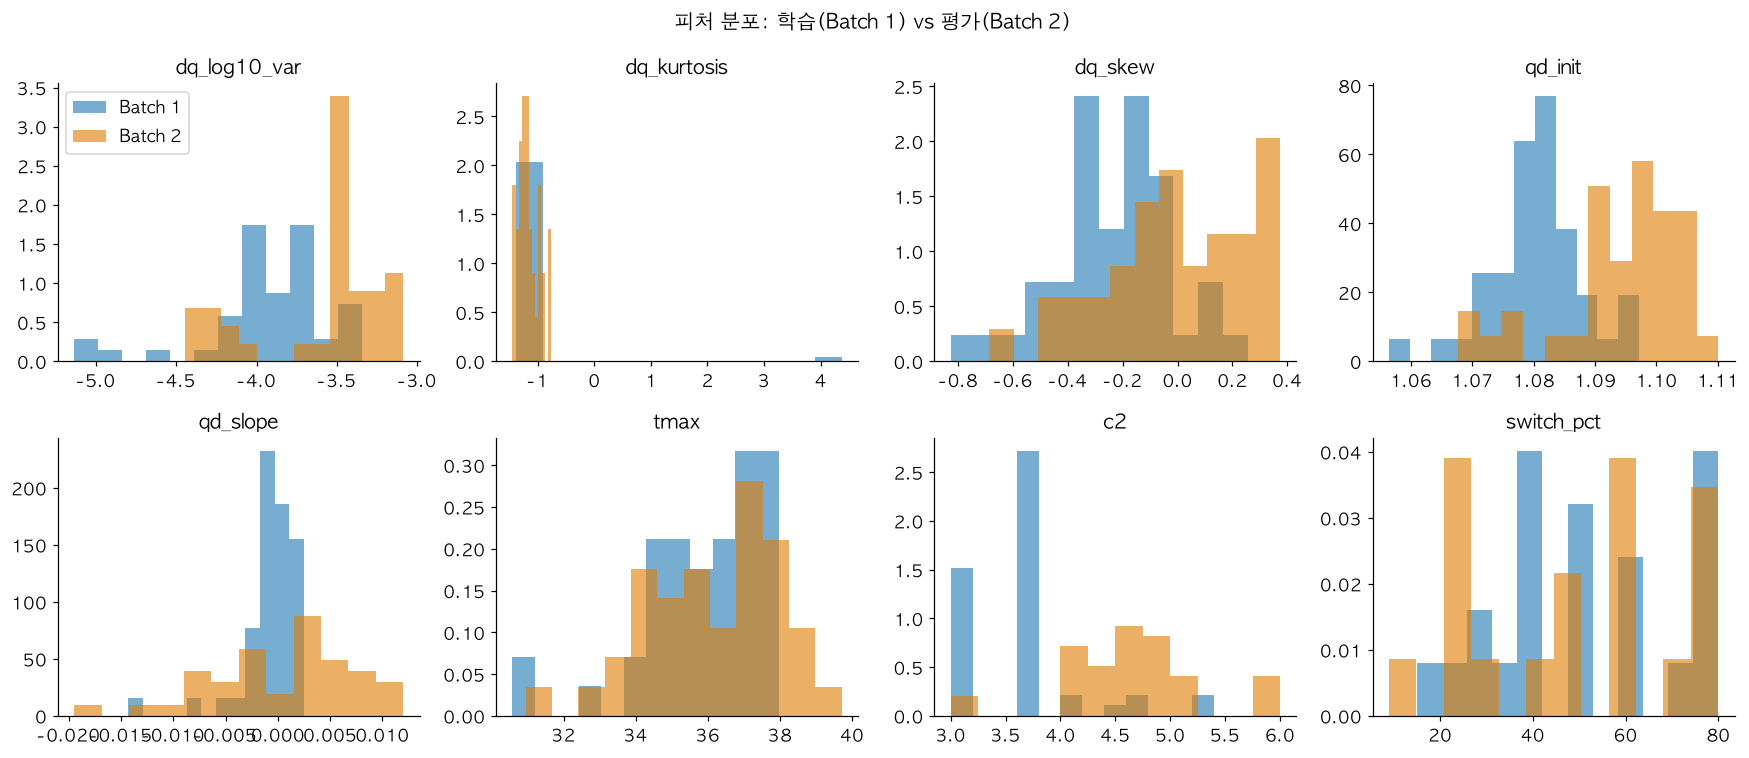

Batch 1 범위 밖 비율(Set A, Batch 2 셀 중): {'dq_log10_var': 0.26, 'dq_kurtosis': 0.1}


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, f in zip(axes.ravel(), FEATURE_SETS["B"]):
    ax.hist(T1[f], bins=12, alpha=.6, color=C["batch1"], label="Batch 1", density=True)
    ax.hist(T2[f], bins=12, alpha=.6, color=C["batch2"], label="Batch 2", density=True)
    ax.set_title(f)
axes[0, 0].legend()
fig.suptitle("피처 분포: 학습(Batch 1) vs 평가(Batch 2)")
plt.tight_layout(); fig.savefig(FIGURES_DIR / "p_feature_shift.png", bbox_inches="tight"); plt.show()
print("Batch 1 범위 밖 비율(Set A, Batch 2 셀 중):",
      {f: round(float(((T2[f] < T1[f].min()) | (T2[f] > T1[f].max())).mean()), 2) for f in FEATURE_SETS["A"]})

**시사점**: 평가 배치에서 학습 범위를 벗어나는 피처가 있는지 위 비율로 확인했습니다. 이는 `03_modeling`의 오류 분석(학습 피처 범위 밖 셀)과 연결됩니다.